## Calculo de Peso Corporal sin el uso de una Báscula

# https://www.openintro.org/data/index.php?data=bdims

In [1]:
# 1) IMPORTS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import joblib  # para guardar el modelo


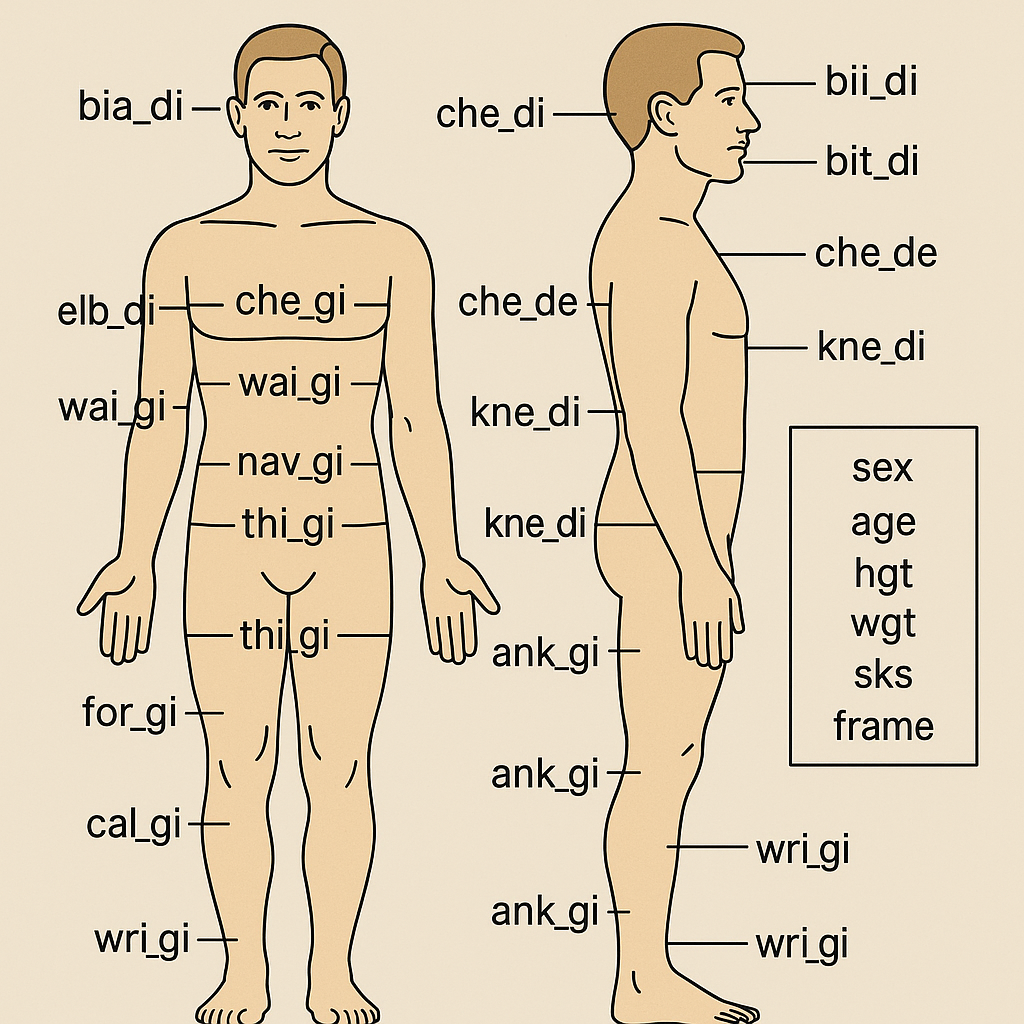

In [2]:
# 2) CARGA DE DATOS
#    Asegúrate de tener 'bdims.csv' en la misma carpeta
ruta_archivo = "bdims.csv"  # cámbialo si lo llamaste distinto

data = pd.read_csv(ruta_archivo)

print("Columnas disponibles:\n", data.columns)
print("\nPrimeras filas:")
display(data.head())

Columnas disponibles:
 Index(['bia_di', 'bii_di', 'bit_di', 'che_de', 'che_di', 'elb_di', 'wri_di',
       'kne_di', 'ank_di', 'sho_gi', 'che_gi', 'wai_gi', 'nav_gi', 'hip_gi',
       'thi_gi', 'bic_gi', 'for_gi', 'kne_gi', 'cal_gi', 'ank_gi', 'wri_gi',
       'age', 'wgt', 'hgt', 'sex'],
      dtype='object')

Primeras filas:


,bia_di,bii_di,bit_di,che_de,che_di,elb_di,wri_di,kne_di,ank_di,sho_gi,...,bic_gi,for_gi,kne_gi,cal_gi,ank_gi,wri_gi,age,wgt,hgt,sex
0,42.9,26.0,31.5,17.7,28.0,13.1,10.4,18.8,14.1,106.2,...,32.5,26.0,34.5,36.5,23.5,16.5,21,65.6,174.0,1
1,43.7,28.5,33.5,16.9,30.8,14.0,11.8,20.6,15.1,110.5,...,34.4,28.0,36.5,37.5,24.5,17.0,23,71.8,175.3,1
2,40.1,28.2,33.3,20.9,31.7,13.9,10.9,19.7,14.1,115.1,...,33.4,28.8,37.0,37.3,21.9,16.9,28,80.7,193.5,1
3,44.3,29.9,34.0,18.4,28.2,13.9,11.2,20.9,15.0,104.5,...,31.0,26.2,37.0,34.8,23.0,16.6,23,72.6,186.5,1
4,42.5,29.9,34.0,21.5,29.4,15.2,11.6,20.7,14.9,107.5,...,32.0,28.4,37.7,38.6,24.4,18.0,22,78.8,187.2,1


In [3]:
# 3) SELECCIÓN DE VARIABLES
#    y preparación de X (inputs) e y (salida: peso)
# Variable objetivo: peso
y = data["wgt"].astype(float)  # kg

# Escoge las medidas corporales que quieras usar como predictores
caracteristicas = [
    "sex",      # sexo 
    "age",     # edad años
    "hgt",    # altura cm
    "che_gi", # Perimetro de pecho cm
    "nav_gi", # Perimetro de abdominal al nivel del ombligo cm
    "sho_gi", # Perimetro de hombros a la altura de axilas cm
    "thi_gi", # Perimetro muslo promedio cm
]

# Filtramos solo las columnas seleccionadas
X = data[caracteristicas].copy()

# Por si hubiera valores faltantes, los limpiamos rápido (versión simple)
# Podrías hacer algo más sofisticado si quieres.
X = X.dropna()
y = y.loc[X.index]

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (507, 7)
Shape y: (507,)


In [4]:
# 4) TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (405, 7)
Tamaño prueba: (102, 7)


In [5]:
# 5) PIPELINE: ESCALADO + REGRESIÓN
#    Voy a entrenar dos modelos:
#    - Regresión lineal
#    - Ridge (con regularización)
# =============================================
# Pipeline con Regresión Lineal
pipe_lin = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe_lin.fit(X_train, y_train)

# Predicción en train y test
y_train_pred_lin = pipe_lin.predict(X_train)
y_test_pred_lin = pipe_lin.predict(X_test)

rmse_train_lin = np.sqrt(mean_squared_error(y_train, y_train_pred_lin))
rmse_test_lin = np.sqrt(mean_squared_error(y_test, y_test_pred_lin))

r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_test_pred_lin)

print("=== Regresión Lineal ===")
print(f"RMSE train: {rmse_train_lin:0.3f} kg")
print(f"RMSE test : {rmse_test_lin:0.3f} kg")
print(f"R² train  : {r2_train_lin:0.3f}")
print(f"R² test   : {r2_test_lin:0.3f}")


=== Regresión Lineal ===
RMSE train: 3.087 kg
RMSE test : 2.956 kg
R² train  : 0.948
R² test   : 0.944


In [6]:
# 6) MODELO RIDGE (por si quieres ver si mejora algo)
#    alpha controla la fuerza de la regularización
# =============================================
pipe_ridge = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipe_ridge.fit(X_train, y_train)

y_train_pred_ridge = pipe_ridge.predict(X_train)
y_test_pred_ridge = pipe_ridge.predict(X_test)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print("\n=== Regresión Ridge ===")
print(f"RMSE train: {rmse_train_ridge:0.3f} kg")
print(f"RMSE test : {rmse_test_ridge:0.3f} kg")
print(f"R² train  : {r2_train_ridge:0.3f}")
print(f"R² test   : {r2_test_ridge:0.3f}")



=== Regresión Ridge ===
RMSE train: 3.087 kg
RMSE test : 2.956 kg
R² train  : 0.948
R² test   : 0.944


In [7]:
# 7) COEFICIENTES DEL MODELO LINEAL
# =============================================
# OJO: Los coeficientes son sobre variables estandarizadas.
# Sirven para ver qué medida "pesa" más en el modelo.
modelo_lin = pipe_lin.named_steps["model"]
scaler = pipe_lin.named_steps["scaler"]

coeficientes = pd.DataFrame({
    "variable": caracteristicas,
    "coef_estandarizado": modelo_lin.coef_
}).sort_values(by="coef_estandarizado", ascending=False)

coeficientes


,variable,coef_estandarizado
6,thi_gi,3.747680
3,che_gi,3.593934
2,hgt,3.441478
5,sho_gi,2.702138
4,nav_gi,2.301787
0,sex,1.391283
1,age,0.146857


In [8]:
# 8) EXPORTAR COEFICIENTES A EXCEL
# =============================================
coeficientes.to_excel("modelo_peso_coeficientes.xlsx", index=False)
print("Coeficientes guardados en 'modelo_peso_coeficientes.xlsx'")


Coeficientes guardados en 'modelo_peso_coeficientes.xlsx'


In [9]:
# 9) FUNCIÓN PARA ESTIMAR PESO DE UNA PERSONA Juan Jose Torres Sastre
# =============================================

def estimar_peso(
    sex, age, hgt, che_gi, nav_gi, sho_gi, thi_gi,
    modelo=pipe_lin
):
    """
    Devuelve el peso estimado (kg) dada una serie de medidas corporales.
    Las unidades deben ser las mismas que en el dataset (cm, mm, etc. según aplique).
    """
    datos_nuevo = pd.DataFrame([{
        "sex": sex, # sexo 1.- Hombre 0.-Mujer
        "age": age, # edad años
        "hgt": hgt, # altura cm
        "che_gi": che_gi, # diametro de pecho cm
        "nav_gi": nav_gi,  # Perimetro de cintura cm
        "sho_gi": sho_gi, # Perimetro de hombros a la altura de axilas cm
        "thi_gi": thi_gi # Perimetro muslo promedio cm
    }])
    
    peso_predicho = modelo.predict(datos_nuevo)[0]
    return peso_predicho

# Ejemplo de uso (ajusta medidas corporales conforme a nomenclatura bdims):
peso_est = estimar_peso(
    sex=1,     # sexo 1.- Hombre 0.-Mujer
    age=52,    # edad años
    hgt=175,   # altura cm
    che_gi=128,  # Perimetro de pecho cm
    nav_gi=113,  # Perimetro de cintura cm
    sho_gi=80,  # Perimetro de hombros a la altura de axilas cm
    thi_gi=70   # Perimetro de muslo promedio
)
print(f"Peso estimado: {peso_est:0.1f} kg")


Peso estimado: 94.7 kg


In [10]:
# 10) GUARDAR MODELO ENTRENADO
# =============================================
joblib.dump(pipe_lin, "modelo_peso_lineal.pkl")
joblib.dump(pipe_ridge, "modelo_peso_ridge.pkl")

print("Modelos guardados como 'modelo_peso_lineal.pkl' y 'modelo_peso_ridge.pkl'")


Modelos guardados como 'modelo_peso_lineal.pkl' y 'modelo_peso_ridge.pkl'


In [11]:
# 11) %% EJEMPLO PARA CARGARLO EN OTRO SCRIPT / NOTEBOOK DIFERENTE A ESTE
import joblib
import pandas as pd
#Carlitos
pipe_cargado = joblib.load("modelo_peso_lineal.pkl")

# Crear un DataFrame con las mismas columnas
nuevos_datos = pd.DataFrame([{
    "sex": 1,     # Sexo
    "age": 37,    # Edad
    "hgt": 178,   # Altura
    "che_gi": 112, # Perimetro de pecho
    "nav_gi": 115,  # Perimetro de cintura pasando por ombligo
    "sho_gi": 125,  # Perimetro de hombros a la altura de axilas cm
    "thi_gi": 63   # Perimetro de muslo promedio
}])

peso_est = pipe_cargado.predict(nuevos_datos)[0]
print("Peso estimado (modelo cargado):", round(peso_est, 1), "kg")


Peso estimado (modelo cargado): 96.2 kg


In [12]:
# 11) %% EJEMPLO PARA CARGARLO EN OTRO SCRIPT / NOTEBOOK DIFERENTE A ESTE
import joblib
import pandas as pd
#JJTS
pipe_cargado = joblib.load("modelo_peso_lineal.pkl")

# Crear un DataFrame con las mismas columnas
nuevos_datos = pd.DataFrame([{
    "sex": 1,     # Sexo
    "age": 52,    # Edad
    "hgt": 175,   # Altura
    "che_gi": 120, # Perimetro de pecho
    "nav_gi": 112,  # Perimetro de cintura pasando por ombligo
    "sho_gi": 132,  # Perimetro de hombros a la altura de axilas cm
    "thi_gi": 51   # Perimetro de muslo promedio
}])

peso_est = pipe_cargado.predict(nuevos_datos)[0]
print("Peso estimado (modelo cargado):", round(peso_est, 1), "kg")


Peso estimado (modelo cargado): 89.3 kg


In [13]:
# 11) %% Juan José Torres Sastré 27-Ene-2026
import joblib
import pandas as pd
#Carlitos
pipe_cargado = joblib.load("modelo_peso_lineal.pkl")

# Crear un DataFrame con las mismas columnas
nuevos_datos = pd.DataFrame([{
    "sex": 1,     # Sexo
    "age": 52,    # Edad
    "hgt": 175,   # Altura
    "che_gi": 109, # Perimetro de pecho
    "nav_gi": 105,  # Perimetro de cintura pasando por ombligo
    "sho_gi": 125,  # Perimetro de hombros a la altura de axilas cm
    "thi_gi": 59   # Perimetro de muslo promedio
}])

peso_est = pipe_cargado.predict(nuevos_datos)[0]
print("Peso estimado (modelo cargado):", round(peso_est, 1), "kg")

Peso estimado (modelo cargado): 88.6 kg
